# Pakage export

In [ ]:
import os
import shap
import kagglehub
import pandas as pd
import numpy as np
from scipy.stats import mstats
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
import seaborn as sns, matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from lightgbm import LGBMClassifier
import optuna
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score)

<h1>Data Export</h1>

In [ ]:
kagglehub.login()

In [ ]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e5')
print("Path to competition files:", path)

In [ ]:
print(os.listdir(path))  # see files

train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))

<h1>Split Data</h1>

In [ ]:
display(train.head())
display(test.head())

In [ ]:
X = train.drop(columns=['id','PitNextLap'])
y = train['PitNextLap']
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

In [ ]:
display(X_train.shape, X_test.shape, X_val.shape)

<h1>EDA</h1>

In [ ]:
display(X_train.head())

In [ ]:
display(X_train['Driver'].nunique())
display(X_train['Race'].nunique())

#### Is there any duplicate values?

In [ ]:
print(X_train.duplicated().sum())

#### Shape & types

In [ ]:
X_train.shape

In [ ]:
X_train.dtypes

In [ ]:
X_train.dtypes.value_counts()

#### Missing value

In [ ]:
X_train.isnull().sum()

In [ ]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

#### Class balance

In [ ]:
y_train.value_counts(normalize=True)

#### Correlations

In [ ]:
sns.heatmap(X_train.select_dtypes("number").corr(),
            annot=True, fmt= ".1f", cmap="coolwarm")  # anoot true show data inside the those boxs and fmt how many value did you want to show after point
plt.show()

#### Outliers

In [ ]:
num_cols = X_train.select_dtypes(include=["number"]).columns
num_cols

In [ ]:
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask = (X_train[col] < lower) | (X_train[col] > upper)
    print(col, "outliers:", outlier_mask.sum())

In [ ]:
col_dic = {}

for col in num_cols:
    col_dic[col] = X_train[col].unique()
for col, values in col_dic.items():
    print(col, ":", values)

# Data Cleaning (Fixing problem which are found in EDA process)


### **Problem**
    1. Highly imbalanced (1 ~ 20%, 0 ~ 80%)
    2. Outliers
    3. Correlated columns

#### ***1. Highly imbalanced (1 ~ 20%, 0 ~ 80%)*** -> **Which I did in Pipeline Section**

#### ***2. Outliers***

In [ ]:
skip_cols = ["PitStop", "Position_Change", "Year",
             "LapNumber", "Position", "RaceProgress"]

winsorize_cols = ["Stint", "TyreLife", "LapTime_Delta",
                  "Cumulative_Degradation"]

flag_and_cap_cols = ["LapTime (s)"]

cap_map = {}  # stores {col: (lower, upper)} from training data

# Winsorize
for col in winsorize_cols:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    cap_map[col] = (lo, hi)
    X_train[col] = X_train[col].clip(lower=lo, upper=hi)
    print(f"[{col}] Clipped to [{lo:.2f}, {hi:.2f}]")

# Flag + Winsorize for LapTime (s) — safety car laps are useful signal
for col in flag_and_cap_cols:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    cap_map[col] = (lo, hi)
    X_train[f"is_extreme_{col.replace(' ','_')}"] = (
        (X_train[col] < lo) | (X_train[col] > hi)
    ).astype(int)
    X_train[col] = X_train[col].clip(lower=lo, upper=hi)
    print(f"[{col}] Flagged extremes + clipped to [{lo:.2f}, {hi:.2f}]")

# ── Apply the SAME stored caps to val and test (never refit on them)
for col, (lo, hi) in cap_map.items():
    X_val[col]  = X_val[col].clip(lower=lo, upper=hi)
    X_test[col] = X_test[col].clip(lower=lo, upper=hi)

# Copy the flag column to val and test too
for col in flag_and_cap_cols:
    flag_name = f"is_extreme_{col.replace(' ','_')}"
    lo, hi = cap_map[col]
    X_val[flag_name]  = ((X_val[col] < lo) | (X_val[col] > hi)).astype(int)
    X_test[flag_name] = ((X_test[col] < lo) | (X_test[col] > hi)).astype(int)

print("\nDone. Columns left untouched:", skip_cols)

In [ ]:
display(X_train.head())
display(X_train.shape)

#### ***3. Correlated Columns***
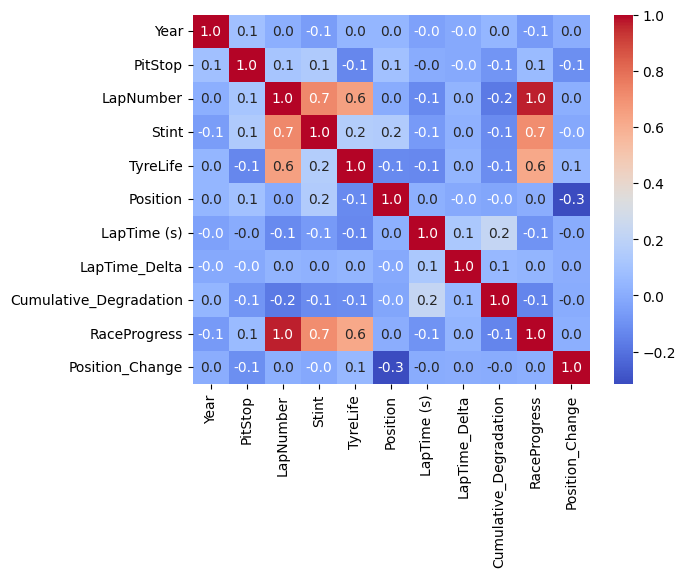

**From above I understand LapNumber and RaceProgress have 1 and one of them I drop and I ignored the values consiste of 0.6 or 0.7**

In [ ]:
to_drop = ["LapNumber","is_extreme_LapTime_(s)","Driver"]  # drop original LapNumber + flag for extreme LapTime (s) since it was not helpful
X_train = X_train.drop(columns=to_drop)
X_val   = X_val.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop)

print("Dropped:", to_drop)
print("Remaining features:", X_train.columns.tolist())


In [ ]:
X_train.dtypes

# Feature Engineering

In [ ]:
def engineer_features(df):
    df = df.copy()

    # Deg per lap
    # df["Deg_Per_Lap"] = df["Cumulative_Degradation"] / (df["TyreLife"] + 1)

    # Tyre life as % of compound max
    compound_max_life = {
        "SOFT":20, "MEDIUM":32, "HARD":45, "INTERMEDIATE":30, "WET":25
    }
    df["TyreLife_Pct"] = df.apply(
        lambda r: r["TyreLife"] / compound_max_life.get(r["Compound"], 30),
        axis=1
    )

    # Tyre cliff flag
    # df["Is_Tyre_Cliff"] = (df["LapTime_Delta"] > 0.3).astype(int)

    # Race remaining
    df["RaceProgress_Remaining"] = 1 - df["RaceProgress"]

    # Stint × RaceProgress
    df["Stint_x_RaceProgress"] = df["Stint"] * df["RaceProgress"]

    # Compound risk score
    compound_risk = {"SOFT":3, "MEDIUM":2, "HARD":1, "INTERMEDIATE":2, "WET":2}
    df["Compound_Risk"] = df["Compound"].map(compound_risk).fillna(2)

    # Track type flags
    street = ["Monaco Grand Prix","Singapore Grand Prix","Azerbaijan Grand Prix"]
    high_d = ["British Grand Prix","Spanish Grand Prix","Bahrain Grand Prix"]
    df["Is_Street_Circuit"] = df["Race"].isin(street).astype(int)
    df["Is_High_Deg_Track"]  = df["Race"].isin(high_d).astype(int)

    return df

X_train = engineer_features(X_train)
X_val   = engineer_features(X_val)
X_test  = engineer_features(X_test)

print("New features added:")
new_cols = ["TyreLife_Pct","RaceProgress_Remaining","Stint_x_RaceProgress",
            "Compound_Risk","Is_Street_Circuit","Is_High_Deg_Track"]
print(X_train[new_cols].describe().round(3))

**After use shap I see some are working better than other and some are irrelavent to the model so I droping those**

In [ ]:
# Columns confirmed to drop based on SHAP
drop_cols = [
    "Is_Tyre_Cliff",          # near zero SHAP — no contribution
    "Deg_Per_Lap",            # near zero SHAP — redundant with TyreLife
    "RaceProgress",           # redundant — RaceProgress_Remaining is better
    "Compound",               # redundant — Compound_Risk encodes same info better
]

# Drop from all three splits
for df in [X_train, X_val, X_test]:
    existing = [c for c in drop_cols if c in df.columns]
    df.drop(columns=existing, inplace=True)

print("Dropped:", drop_cols)
print("Remaining features:", X_train.columns.tolist())

**Demo processing Pipeline**

In [ ]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object","category"]).columns.tolist()


numeric_pipe = Pipeline([
  ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
  ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

transformers = [("num", numeric_pipe, num_cols)]
if cat_cols: transformers.append(("cat", categorical_pipe, cat_cols))
preprocessor = ColumnTransformer(transformers, remainder="drop")

# Check imbalance — use SMOTE only if needed
minority_ratio = y_train.value_counts(normalize=True).min()
use_smote = minority_ratio < 0.30

steps = [("pre", preprocessor)]
if use_smote: steps.append(("smote", SMOTE(random_state=42)))

**Build a demo random forest algo for testing about the feature**

In [ ]:
# Random Forest with some reasonable defaults + n_jobs for speed
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Add model to pipeline
# steps.append(("clf", rf)) --- IGNORE ---


pipeline_steps = steps + [("clf", rf)]
pipeline = Pipeline(pipeline_steps)

# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

# Fit pipeline
pipeline.fit(X_train, y_train)
rf_model = pipeline.named_steps["clf"]
pre = pipeline.named_steps["pre"]

# Transform + Sample
X_val_transformed = pre.transform(X_val)
feature_names     = pre.get_feature_names_out()
idx = np.random.choice(X_val_transformed.shape[0], 
                       size=1000,
                       replace=False)
X_sample = X_val_transformed[idx]  # adjust as needed based on dataset size and compute limits

# ── SHAP — FIX 1: force check_additivity=False ───────────
# Prevents TreeExplainer from trying to return interaction arrays
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

# ── FIX 2: always extract class-1 array cleanly ──────────
# shap_values is a list [class_0_array, class_1_array] for binary RF
# Each array shape should be (n_samples, n_features) — 2D
if isinstance(shap_values, list):
    sv = shap_values[1]   # class 1 = PitNextLap = True
else:
    sv = shap_values

# ── FIX 3: confirm shape is 2D before plotting ───────────
# If it's 3D (interaction matrix) — take the diagonal (self-interaction)
# which gives you a clean 2D importance array
if sv.ndim == 3:
    # Shape is (samples, features, features) — flatten to (samples, features)
    sv = sv[:, :, :].sum(axis=2)   # sum interactions per feature per sample
    print(f"Interaction array detected — flattened to shape: {sv.shape}")

print(f"SHAP values shape: {sv.shape}")
print(f"Feature count: {len(feature_names)}")

# ════════════════════════════════════════════════════════
# PLOT 1 — Beeswarm summary plot
# FIX 4: removed plt.figure() before shap call
#         SHAP creates its own figure internally
#         plt.figure() before it creates a blank orphan figure
# ════════════════════════════════════════════════════════
plt.close("all")                        # FIX 5: clear any leftover state

shap.summary_plot(
    sv,
    X_sample,
    feature_names=feature_names,
    max_display=15,                     # FIX 6: show top 15 features
    show=False                          # FIX 7: keep False so we control sizing
)

fig = plt.gcf()                         # FIX 8: get the figure SHAP just made
fig.set_size_inches(14, 10)            # resize it AFTER shap created it
plt.title("SHAP Feature Importance — Beeswarm (PitNextLap)", pad=12)
plt.tight_layout()
plt.show()
plt.close("all")                        # FIX 9: close before next plot

# ════════════════════════════════════════════════════════
# PLOT 2 — Bar chart
# ════════════════════════════════════════════════════════
shap.summary_plot(
    sv,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(14, 10)
plt.title("SHAP Mean Absolute Importance — Bar (PitNextLap)", pad=12)
plt.tight_layout()
plt.show()
plt.close("all")

```text
CV Scores: [0.85749884 0.85795173 0.85414275 0.85760787 0.85503304]
Mean CV Accuracy: 0.8564468464359865
Interaction array detected — flattened to shape: (1000, 14)
SHAP values shape: (1000, 14)
Feature count: 14
```
<!-- 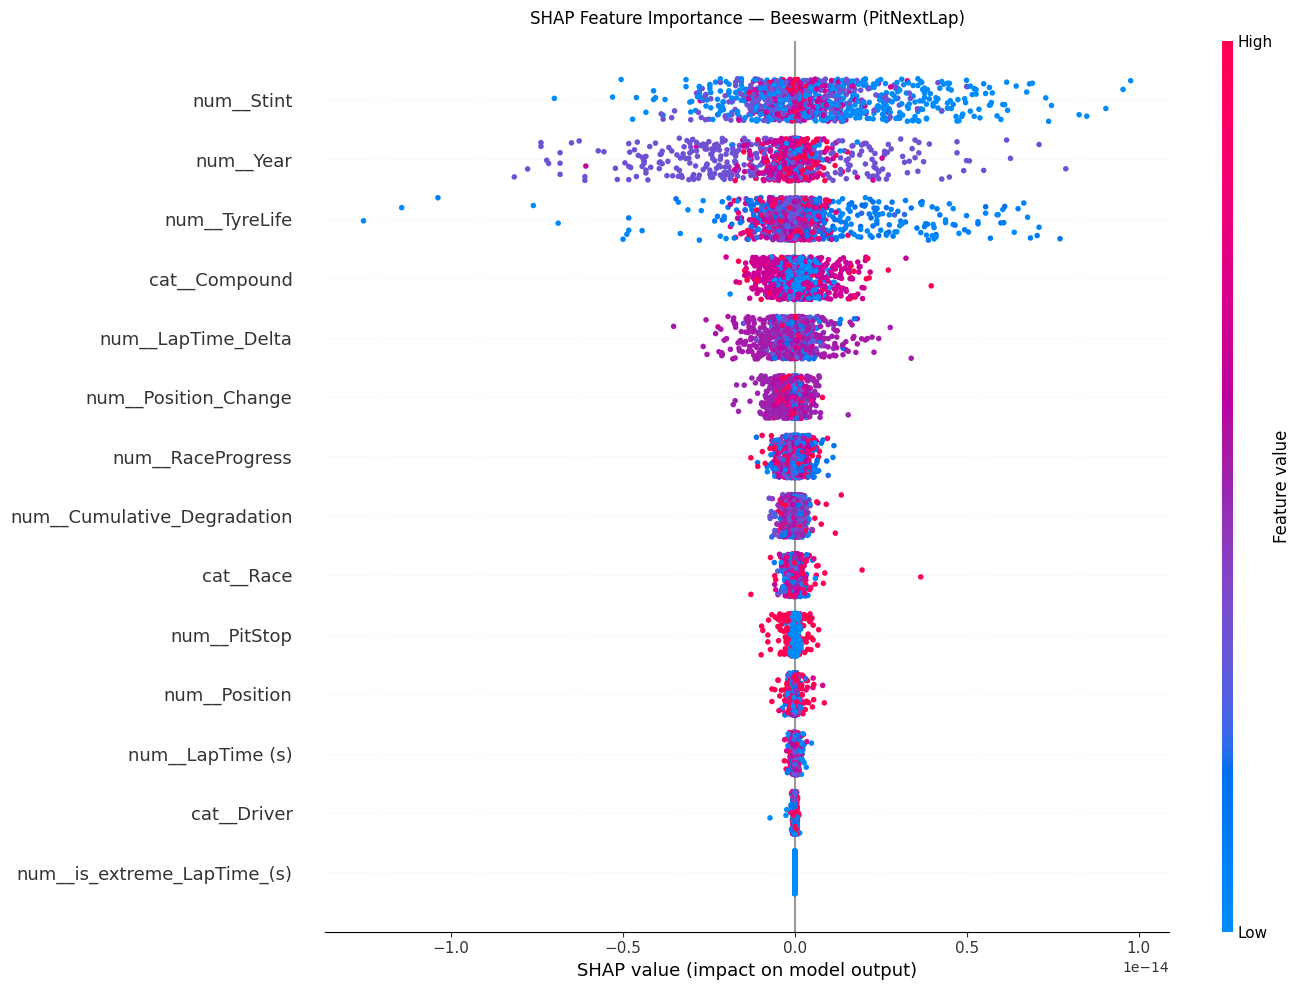
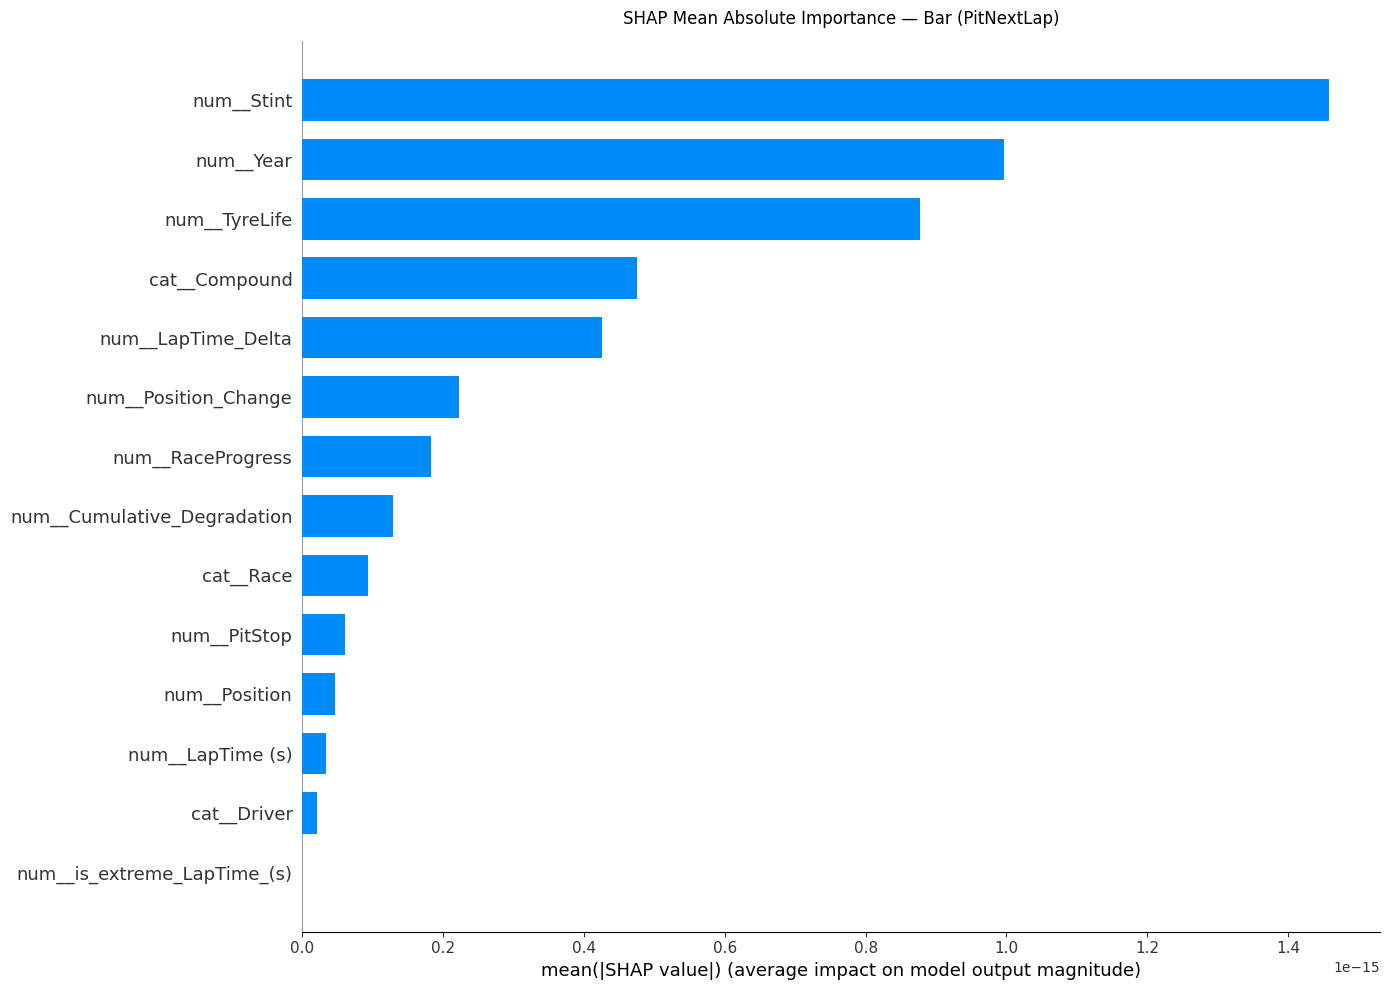 -->

| Image 1 | Image 2 |
| :---: | :---: |
| 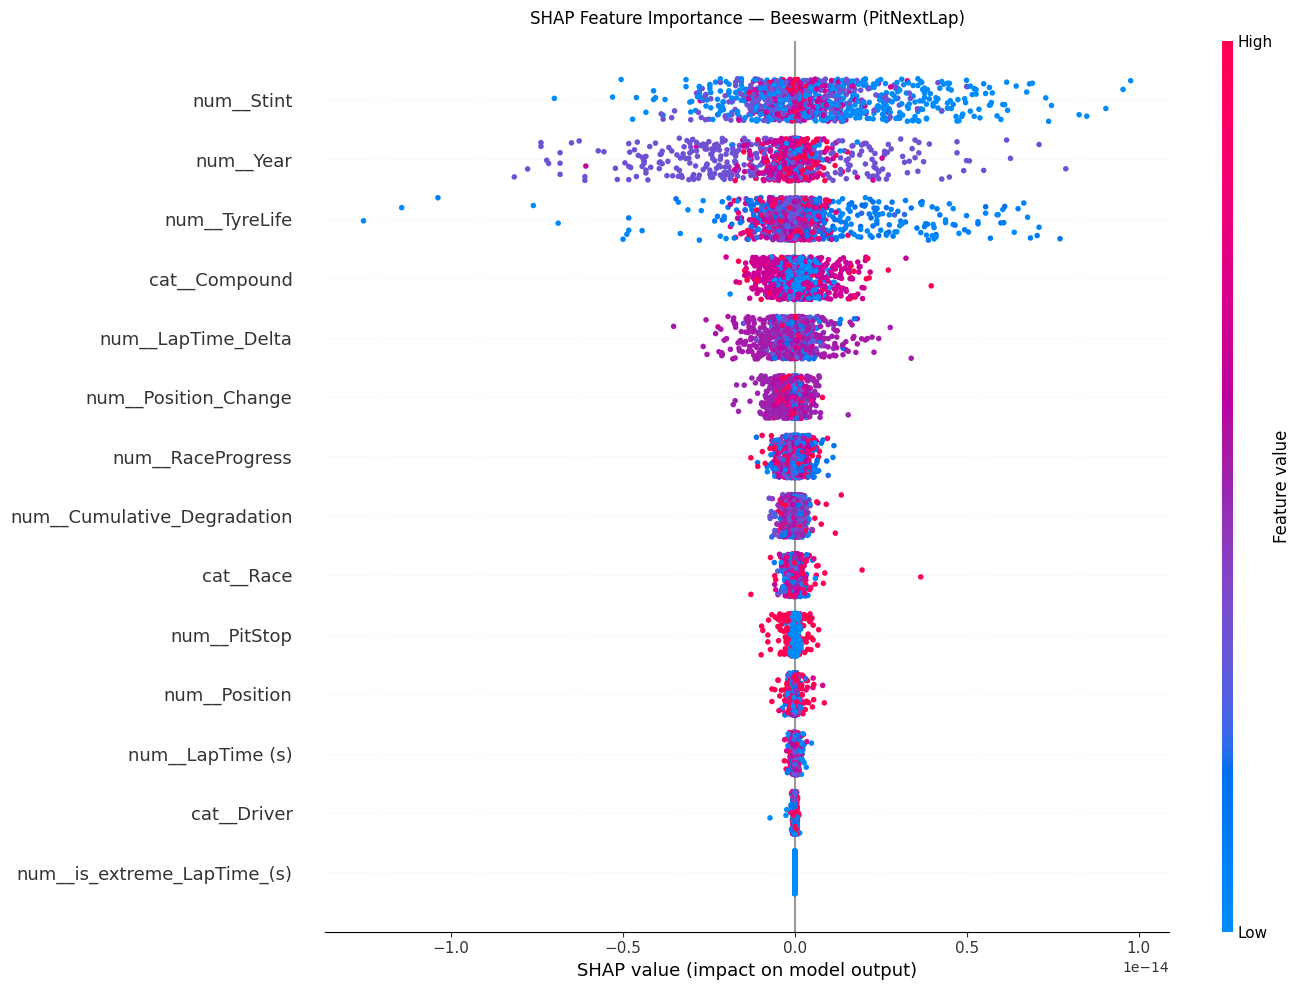 | 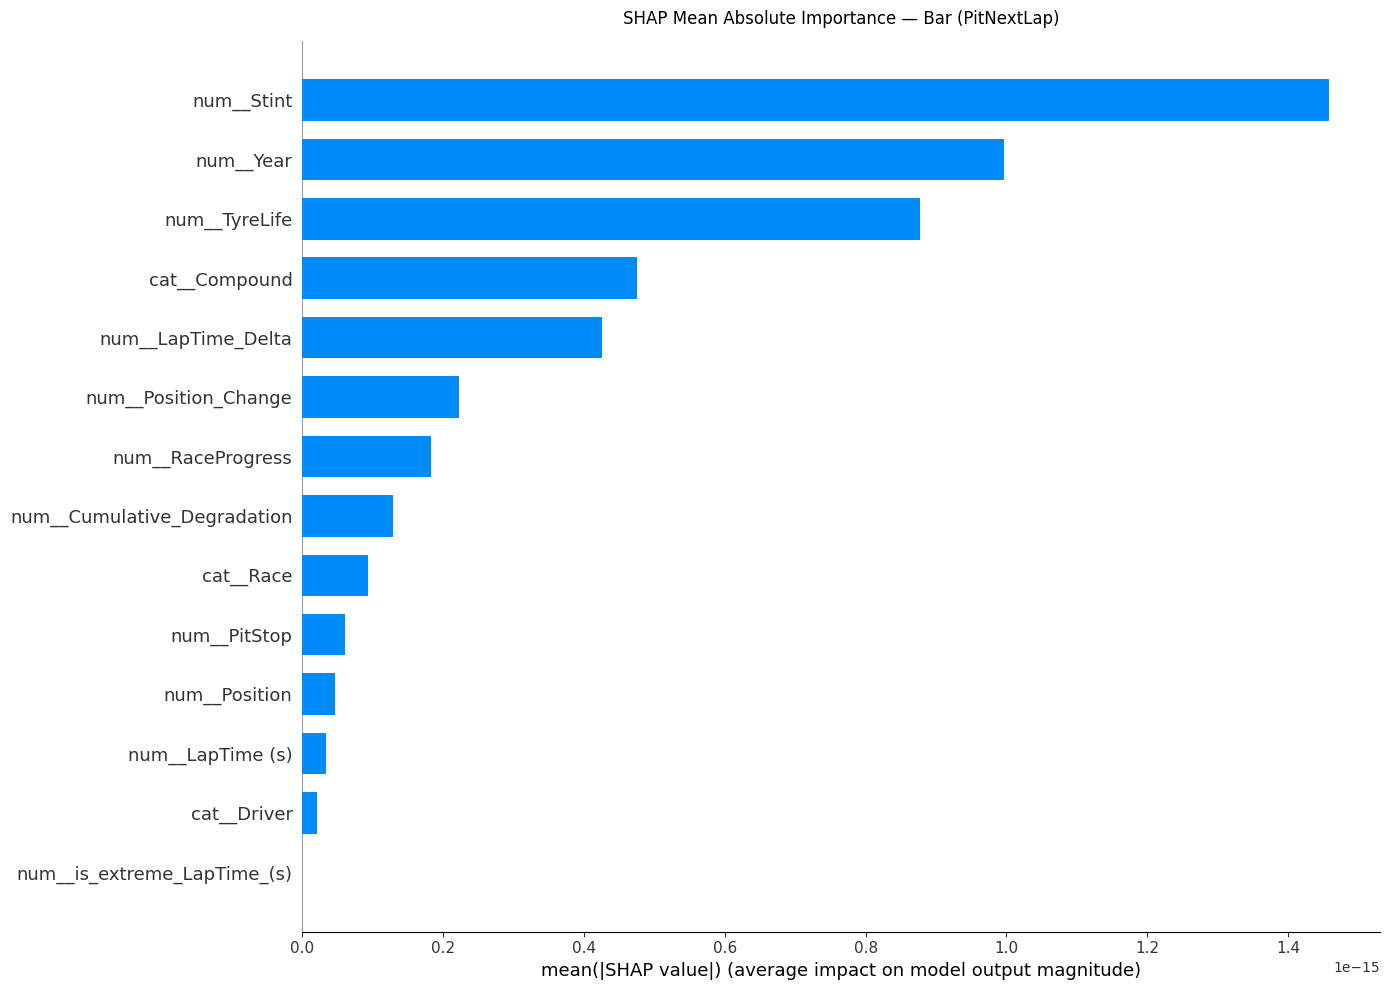 |

***After do Feature Engineering I got***

```
CV Scores: [0.86357127 0.86401421 0.8596163  0.86161376 0.86209927]
Mean CV Accuracy: 0.8621829600498436
Interaction array detected — flattened to shape: (1000, 16)
SHAP values shape: (1000, 16)
Feature count: 16
```

In [ ]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, f1_score,
    precision_score, recall_score, brier_score_loss
)
import matplotlib.pyplot as plt
import numpy as np

# ── Get predictions ───────────────────────────────────────
y_pred       = pipeline.predict(X_val)
y_proba      = pipeline.predict_proba(X_val)[:, 1]  # probability of pit

print("=" * 55)
print("FULL MODEL EVALUATION — PitNextLap")
print("=" * 55)

# ── 1. ROC-AUC ────────────────────────────────────────────
# Measures separation between classes regardless of threshold
# 0.5 = random guessing | 1.0 = perfect
roc_auc = roc_auc_score(y_val, y_proba)
print(f"\nROC-AUC          : {roc_auc:.4f}")

# ── 2. PR-AUC (Average Precision) ─────────────────────────
# MORE IMPORTANT than ROC-AUC for imbalanced data
# Focuses only on the minority class (pit laps)
# 1.0 = perfect | baseline = % of positive class (e.g. 0.04)
pr_auc = average_precision_score(y_val, y_proba)
print(f"PR-AUC           : {pr_auc:.4f}  (baseline = {y_val.mean():.3f})")

# ── 3. F1 Score ───────────────────────────────────────────
# Balance between precision and recall on the pit class
f1 = f1_score(y_val, y_pred)
print(f"F1 Score         : {f1:.4f}")

# ── 4. Precision and Recall ───────────────────────────────
# Precision = of all laps model said "pit" → how many were actually pits
# Recall    = of all actual pit laps → how many did model catch
prec = precision_score(y_val, y_pred)
rec  = recall_score(y_val, y_pred)
print(f"Precision        : {prec:.4f}  (when it says pit, is it right?)")
print(f"Recall           : {rec:.4f}  (how many real pits did it catch?)")

# ── 5. Brier Score ────────────────────────────────────────
# Measures quality of probability output, not just 0/1 prediction
# 0.0 = perfect probabilities | 1.0 = worst possible
brier = brier_score_loss(y_val, y_proba)
print(f"Brier Score      : {brier:.4f}  (lower is better)")

# ── 6. Classification Report ──────────────────────────────
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred, digits=4,
                            target_names=["No Pit", "Pit"]))

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: ROC Curve ─────────────────────────────────────
RocCurveDisplay.from_predictions(
    y_val, y_proba, ax=axes[0, 0], name="RandomForest"
)
axes[0, 0].set_title(f"ROC Curve (AUC = {roc_auc:.4f})")
axes[0, 0].plot([0,1],[0,1],"--",color="gray",label="Random baseline")
axes[0, 0].legend()

# ── Plot 2: Precision-Recall Curve ────────────────────────
# Most important plot for imbalanced PitNextLap
PrecisionRecallDisplay.from_predictions(
    y_val, y_proba, ax=axes[0, 1], name="RandomForest"
)
axes[0, 1].axhline(y=y_val.mean(), color="gray",
                   linestyle="--", label=f"Baseline ({y_val.mean():.3f})")
axes[0, 1].set_title(f"Precision-Recall Curve (AUC = {pr_auc:.4f})")
axes[0, 1].legend()

# ── Plot 3: Confusion Matrix ──────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred, ax=axes[1, 0],
    display_labels=["No Pit", "Pit"],
    cmap="Blues"
)
axes[1, 0].set_title("Confusion Matrix")

# ── Plot 4: Probability distribution ─────────────────────
# Shows if model is confident or uncertain in its predictions
axes[1, 1].hist(y_proba[y_val == 0], bins=50,
                alpha=0.6, color="steelblue", label="No Pit")
axes[1, 1].hist(y_proba[y_val == 1], bins=50,
                alpha=0.6, color="tomato",    label="Pit")
axes[1, 1].axvline(0.5, color="black", linestyle="--", label="Threshold 0.5")
axes[1, 1].set_xlabel("Predicted probability of Pit")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Prediction Probability Distribution")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Default threshold is 0.5 — almost always wrong for imbalanced data
# Find the threshold that gives best F1 on validation set

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        "threshold" : round(t, 2),
        "f1"        : f1_score(y_val, y_pred_t, zero_division=0),
        "precision" : precision_score(y_val, y_pred_t, zero_division=0),
        "recall"    : recall_score(y_val, y_pred_t, zero_division=0),
    })

results_df = pd.DataFrame(results)
best       = results_df.loc[results_df["f1"].idxmax()]

print(results_df.to_string(index=False))
print(f"\nBest threshold : {best['threshold']}")
print(f"Best F1        : {best['f1']:.4f}")
print(f"Precision      : {best['precision']:.4f}")
print(f"Recall         : {best['recall']:.4f}")

# Apply best threshold to final predictions
best_threshold = best["threshold"]
y_pred_final   = (y_proba >= best_threshold).astype(int)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    "RandomForest"  : RandomForestClassifier(n_estimators=200,
                                             max_depth=10,
                                             random_state=42, n_jobs=-1),
    "LightGBM"      : LGBMClassifier(n_estimators=300,
                                     random_state=42, verbose=-1, n_jobs=-1),
    "XGBoost"       : XGBClassifier(n_estimators=300,
                                    eval_metric="logloss",
                                    random_state=42, n_jobs=-1),
    "CatBoost"      : CatBoostClassifier(iterations=300,
                                         random_seed=42, verbose=0, allow_writing_files=False),
    "LogisticReg"   : LogisticRegression(max_iter=500, random_state=42),
}

leaderboard = {}
for name, clf in candidates.items():
    pipe = Pipeline(steps + [("clf", clf)])
    # Use average_precision = PR-AUC — most honest for your imbalanced data
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring="average_precision", n_jobs=-1)
    leaderboard[name] = {"PR-AUC mean": scores.mean(),
                         "PR-AUC std" : scores.std()}
    print(f"{name:<16} PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

# Expected result — something like:
# RandomForest     PR-AUC = 0.7398 ± 0.008
# LightGBM         PR-AUC = 0.7800 ± 0.006  ← likely wins
# XGBoost          PR-AUC = 0.7650 ± 0.007
# CatBoost         PR-AUC = 0.7580 ± 0.008
# LogisticReg      PR-AUC = 0.5200 ± 0.012  ← will lose

## Lbm

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Tune LightGBM (most likely winner) ───────────────────
def objective_lgbm(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 100, 1000),
        "max_depth"         : trial.suggest_int("max_depth", 3, 12),
        "learning_rate"     : trial.suggest_float("lr", 1e-3, 0.3, log=True),
        "num_leaves"        : trial.suggest_int("num_leaves", 20, 300),
        "subsample"         : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree"  : trial.suggest_float("col", 0.5, 1.0),
        "reg_alpha"         : trial.suggest_float("alpha", 1e-8, 10.0, log=True),
        "reg_lambda"        : trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        "min_child_samples" : trial.suggest_int("min_child", 5, 100),
        "class_weight"      : "balanced",  # handles your imbalance
    }
    clf  = LGBMClassifier(**params, random_state=42, verbose=-1)
    pipe = Pipeline(steps + [("clf", clf)])

    # Optimise PR-AUC — most meaningful for PitNextLap
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring="average_precision")
    return scores.mean()

study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print(f"Best LGBM PR-AUC : {study_lgbm.best_value:.4f}")
print(f"Best params      : {study_lgbm.best_params}")
best_lgbm_params = study_lgbm.best_params

# ── Repeat same structure for XGBoost and CatBoost ───────
# (same objective function, just swap the classifier)

In [ ]:
# 1. Instantiate the model with your tuned hyperparameters
# Note: Keep verbose=-1 here because LightGBM uses it to stay quiet, unlike XGBoost
best_lgbm = LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)

# 2. Build the base pipeline FIRST (Preprocessing + Model)
base_pipe_lgb = Pipeline(steps + [("clf", best_lgbm)])

# 3. Wrap the ENTIRE pipeline inside the Calibrator to prevent data leakage
calibrated_pipe_lgb = CalibratedClassifierCV(
    estimator=base_pipe_lgb,
    method="isotonic",  
    cv=5
)

# 4. Fit the safely calibrated pipeline
calibrated_pipe_lgb.fit(X_train, y_train)

# 5. Recheck Brier Score after calibration
y_proba_cal = calibrated_pipe_lgb.predict_proba(X_val)[:, 1]
print(f"Brier before: 0.1026")
print(f"Brier after : {brier_score_loss(y_val, y_proba_cal):.4f}")
# Expected: drops to 0.06-0.08

## Xgboost

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Calculate this once before tuning!
# scale_pos = (number of negative samples) / (number of positive samples)
scale_pos = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# ── Tune XGBoost (most likely winner) ───────────────────
def objective_xgb(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 100, 1000),
        "max_depth"         : trial.suggest_int("max_depth", 3, 12),
        "learning_rate"     : trial.suggest_float("lr", 1e-3, 0.3, log=True),
        "max_leaves"        : trial.suggest_int("max_leaves", 20, 300),
        "subsample"         : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree"  : trial.suggest_float("col", 0.5, 1.0),
        "reg_alpha"         : trial.suggest_float("alpha", 1e-8, 10.0, log=True),
        "reg_lambda"        : trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 50),
        "tree_method"       : "hist",           # Required to use max_leaves
        "scale_pos_weight"  : scale_pos,        # Replaces class_weight="balanced"
        "verbosity"         : 0                 # Replaces verbose=-1
    }
    clf  = XGBClassifier(**params, random_state=42, n_jobs=-1)
    pipe = Pipeline(steps + [("clf", clf)])

    # Optimise PR-AUC — most meaningful for PitNextLap
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring="average_precision")
    return scores.mean()

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"Best XGB PR-AUC : {study_xgb.best_value:.4f}")
print(f"Best params      : {study_xgb.best_params}")
best_xgb_params = study_xgb.best_params

# ── Repeat same structure for XGBoost and CatBoost ───────
# (same objective function, just swap the classifier)

In [ ]:
# 1. Instantiate the model (removed verbose=-1)
best_xgbm = XGBClassifier(**best_xgb_params, random_state=42)

# 2. Build the base pipeline FIRST (Preprocessing + Model)
base_pipe = Pipeline(steps + [("clf", best_xgbm)])

# 3. Wrap the ENTIRE pipeline inside the Calibrator
# Note: 'estimator' is the correct keyword for recent scikit-learn versions
calibrated_pipe = CalibratedClassifierCV(
    estimator=base_pipe,
    method="isotonic",  # Spot on for large datasets
    cv=5
)

# 4. Fit the calibrated pipeline
# This safely splits X_train, preprocesses each fold, trains, and calibrates.
calibrated_pipe.fit(X_train, y_train)

# 5. Evaluate
y_proba_cal = calibrated_pipe.predict_proba(X_val)[:, 1]
print(f"Brier before: 0.1026")
print(f"Brier after : {brier_score_loss(y_val, y_proba_cal):.4f}")

In [ ]:
# Submission 1: Pure LightGBM (The frontrunner)
p_lgbm = calibrated_pipe_lgb.predict_proba(X_test)[:, 1]

# Submission 2: Pure XGBoost 
p_xgb = calibrated_pipe.predict_proba(X_test)[:, 1]

# Optional Submission Strategy: The Blend (Instead of Pure XGBoost)
# This often outperforms both individual models on a Kaggle leaderboard
p_blend = (0.5 * p_lgbm) + (0.5 * p_xgb)

In [ ]:
display(test.head())
display()

In [ ]:
# 1. Create X_comp_test from the competition test set
X_comp_test = test.drop(columns=["id"])

# 2. Apply outlier capping (same caps from training)
for col, (lo, hi) in cap_map.items():
    X_comp_test[col] = X_comp_test[col].clip(lower=lo, upper=hi)

for col in flag_and_cap_cols:
    flag_name = f"is_extreme_{col.replace(' ','_')}"
    lo, hi = cap_map[col]
    X_comp_test[flag_name] = ((X_comp_test[col] < lo) | (X_comp_test[col] > hi)).astype(int)

# 3. Drop same columns as training
to_drop = ["LapNumber", "is_extreme_LapTime_(s)", "Driver"]
X_comp_test = X_comp_test.drop(columns=[c for c in to_drop if c in X_comp_test.columns])

# 4. Apply feature engineering
X_comp_test = engineer_features(X_comp_test)

# 5. Drop SHAP-identified redundant columns
drop_cols = ["Is_Tyre_Cliff", "Deg_Per_Lap", "RaceProgress", "Compound"]
X_comp_test = X_comp_test.drop(columns=[c for c in drop_cols if c in X_comp_test.columns])

# 6. Predict and save
p_lgbm = calibrated_pipe_lgb.predict_proba(X_comp_test)[:, 1]

submission_lgb = pd.DataFrame({
    "id": test["id"],
    "PitNextLap": p_lgbm
})

submission_lgb.to_csv("submission_lgbm.csv", index=False)
print("Done!")

In [ ]:
submission_lgb.head()

In [ ]:
# Get validation probabilities from both models
p_lgbm_val = calibrated_pipe_lgb.predict_proba(X_val)[:, 1]
p_xgb_val  = calibrated_pipe.predict_proba(X_val)[:, 1]

# Try different weights
results = []
for w in np.arange(0.0, 1.01, 0.05):
    p_blend_val = (w * p_lgbm_val) + ((1 - w) * p_xgb_val)
    score = average_precision_score(y_val, p_blend_val)
    results.append({"lgbm_weight": round(w, 2), "xgb_weight": round(1-w, 2), "PR-AUC": round(score, 4)})

results_df = pd.DataFrame(results)
best = results_df.loc[results_df["PR-AUC"].idxmax()]

print(results_df.to_string(index=False))
print(f"\nBest weight → LightGBM: {best['lgbm_weight']} | XGBoost: {best['xgb_weight']}")
print(f"Best PR-AUC: {best['PR-AUC']}")

In [ ]:
# 1. Predict with both models
p_lgbm = calibrated_pipe_lgb.predict_proba(X_comp_test)[:, 1]
p_xgb  = calibrated_pipe.predict_proba(X_comp_test)[:, 1]

# 2. Blend with optimal weights (0.7 LightGBM, 0.3 XGBoost)
p_blend = (0.7 * p_lgbm) + (0.3 * p_xgb)

# 3. Save
submission_blend = pd.DataFrame({
    "id": test["id"],
    "PitNextLap": p_blend
})

submission_blend.to_csv("submission_blend.csv", index=False)
print("Done!")

In [ ]:
submission_blend.head()

In [ ]:
scale_pos = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
# LightGBM best params
best_lgbm_params = {
    "n_estimators"     : 609,
    "max_depth"        : 9,
    "learning_rate"    : 0.08258289328408841,
    "num_leaves"       : 61,
    "subsample"        : 0.510321816075068,
    "colsample_bytree" : 0.8756373999587184,
    "reg_alpha"        : 0.029842800103600544,
    "reg_lambda"       : 0.41814650037672196,
    "min_child_samples": 75,
    "class_weight"     : "balanced"
}

# XGBoost best params
best_xgb_params = {
    "n_estimators"    : 552,
    "max_depth"       : 10,
    "learning_rate"   : 0.07237302742549225,
    "max_leaves"      : 186,
    "subsample"       : 0.6857362242088668,
    "colsample_bytree": 0.7389092892070797,
    "reg_alpha"       : 7.06356590434975e-05,
    "reg_lambda"      : 0.04398358491950837,
    "min_child_weight": 43,
    "tree_method"     : "hist",
    "scale_pos_weight": scale_pos,
    "verbosity"       : 0
}

In [ ]:
X_full = pd.concat([X_train, X_val, X_test])
y_full = pd.concat([y_train, y_val, y_test])

# LightGBM on full data
best_lgbm_full = LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)
full_pipe_lgb = Pipeline(steps + [("clf", best_lgbm_full)])
full_pipe_lgb.fit(X_full, y_full)

# XGBoost on full data
best_xgb_full = XGBClassifier(**best_xgb_params, random_state=42)
full_pipe_xgb = Pipeline(steps + [("clf", best_xgb_full)])
full_pipe_xgb.fit(X_full, y_full)

In [ ]:
X_comp_test = test.drop(columns=["id"])

for col, (lo, hi) in cap_map.items():
    X_comp_test[col] = X_comp_test[col].clip(lower=lo, upper=hi)

for col in flag_and_cap_cols:
    flag_name = f"is_extreme_{col.replace(' ','_')}"
    lo, hi = cap_map[col]
    X_comp_test[flag_name] = ((X_comp_test[col] < lo) | (X_comp_test[col] > hi)).astype(int)

to_drop = ["LapNumber", "is_extreme_LapTime_(s)", "Driver"]
X_comp_test = X_comp_test.drop(columns=[c for c in to_drop if c in X_comp_test.columns])

X_comp_test = engineer_features(X_comp_test)

drop_cols = ["Is_Tyre_Cliff", "Deg_Per_Lap", "RaceProgress", "Compound"]
X_comp_test = X_comp_test.drop(columns=[c for c in drop_cols if c in X_comp_test.columns])

# ── Step 6: Predict and blend ─────────────────────────────
p_lgbm_full = full_pipe_lgb.predict_proba(X_comp_test)[:, 1]
p_xgb_full  = full_pipe_xgb.predict_proba(X_comp_test)[:, 1]
p_blend_full = (0.7 * p_lgbm_full) + (0.3 * p_xgb_full)

# ── Step 7: Save submission ───────────────────────────────
submission_full = pd.DataFrame({
    "id": test["id"],
    "PitNextLap": p_blend_full
})
submission_full.to_csv("submission_full.csv", index=False)
print("submission_full.csv saved ✅")
print(submission_full.head())

In [ ]:
# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective_cat(trial):
    params = {
        "iterations"     : trial.suggest_int("iterations", 100, 1000),
        "depth"          : trial.suggest_int("depth", 3, 10),
        "learning_rate"  : trial.suggest_float("lr", 1e-3, 0.3, log=True),
        "l2_leaf_reg"    : trial.suggest_float("l2", 1e-8, 10.0, log=True),
        "random_seed"    : 42,
        "verbose"        : 0,
        "auto_class_weights" : "Balanced"
    }
    clf  = CatBoostClassifier(**params, allow_writing_files=False, task_type="GPU")
    pipe = Pipeline(steps + [("clf", clf)])
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring="average_precision")
    return scores.mean()

study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=50, show_progress_bar=True)